# Netmarble Origin iOS — Install-to-Login Rate
**Bundle:** `id6744205088` (Seven Deadly Sins Origin, iOS, AppsFlyer)  
**Objective:** Compare install-to-login conversion rate — Moloco-attributed vs unattributed  
**Data:** `focal-elf-631.df_accesslog.pb` (fully unsampled postback)  
**Lookback:** Last 30 days  
**Attribution:** Moloco = `attribution.attributed = TRUE` AND `moloco.campaign_id IS NOT NULL`

## 0. Setup

In [15]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='moloco-ods')
BUNDLE = 'id6744205088'
MMP    = 'APPSFLYER'

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'\u2705 {label}: {len(df)} rows')
    return df

print('\u2705 Setup complete')

✅ Setup complete


## Section 0 — Event Discovery
Confirm install and login event names. Never hardcode — always discover first.

In [16]:
q0 = """
SELECT
  event.name                          AS event_name,
  COUNT(*)                            AS event_count,
  COUNT(DISTINCT device.idfv)         AS distinct_idfv,
  MIN(DATE(timestamp))                AS first_seen,
  MAX(DATE(timestamp))                AS last_seen
FROM `focal-elf-631.df_accesslog.pb`
WHERE DATE(timestamp) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 3 DAY) AND CURRENT_DATE()
  AND app.bundle = 'id6744205088'
  AND mmp.name = 'APPSFLYER'
GROUP BY event_name
ORDER BY event_count DESC
"""
df0 = run_query(q0, 'Event discovery')
df0

✅ Event discovery: 39 rows


,event_name,event_count,distinct_idfv,first_seen,last_seen
0,login,2215647,219136,2026-04-03,2026-04-06
1,af_app_opened,2036878,249223,2026-04-03,2026-04-06
2,login_1st,1264071,218839,2026-04-03,2026-04-06
3,daily_mission_clear_1,1012924,39070,2026-04-03,2026-04-06
4,path_of_hero_lv1,1007039,146267,2026-04-03,2026-04-06
5,visit_shop,915259,149175,2026-04-03,2026-04-06
6,reward_key_use_100,797448,93702,2026-04-03,2026-04-06
7,path_of_exploration_lv1,724432,84209,2026-04-03,2026-04-06
8,path_of_hero_lv3,717988,84529,2026-04-03,2026-04-06
9,path_of_hero_lv5,649094,73183,2026-04-03,2026-04-06


**Confirmed event names:**
- Install: `install`
- Login: `login` (recurring) + `login_1st` (first login) — both captured by `LIKE '%login%'`

**Schema notes:**
- Bundle requires `id` prefix: `id6744205088`
- MMP name is all-caps: `APPSFLYER`

## Section 1 — Install-to-Login Rate: Moloco vs Unattributed
Device ID resolution priority: `idfv` → `idfa` → `mmp.device_id` (iOS ATT-safe)

In [17]:
q1 = """
WITH
install_events AS (
  SELECT
    CASE
      WHEN device.idfv IS NOT NULL AND device.idfv NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN device.idfv
      WHEN device.idfa IS NOT NULL AND device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN device.idfa
      WHEN mmp.device_id IS NOT NULL AND mmp.device_id != '' THEN mmp.device_id
      ELSE NULL
    END AS user_id,
    timestamp AS install_ts,
    DATE(timestamp) AS install_date,
    CASE
      WHEN attribution.attributed = TRUE AND moloco.campaign_id IS NOT NULL THEN 'Moloco'
      ELSE 'Unattributed'
    END AS attribution_group
  FROM `focal-elf-631.df_accesslog.pb`
  WHERE DATE(timestamp) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 7 DAY) AND CURRENT_DATE()
    AND app.bundle = 'id6744205088'
    AND mmp.name = 'APPSFLYER'
    AND LOWER(event.name) = 'install'
),
installs_deduped AS (
  -- ROW_NUMBER ensures attribution_group comes from the earliest install row,
  -- avoiding ANY_VALUE picking arbitrarily when a user has reinstalls with different attribution.
  SELECT user_id, install_ts, install_date, attribution_group
  FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY install_ts) AS rn
    FROM install_events
    WHERE user_id IS NOT NULL
  )
  WHERE rn = 1
),
login_events AS (
  SELECT
    CASE
      WHEN device.idfv IS NOT NULL AND device.idfv NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN device.idfv
      WHEN device.idfa IS NOT NULL AND device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN device.idfa
      WHEN mmp.device_id IS NOT NULL AND mmp.device_id != '' THEN mmp.device_id
      ELSE NULL
    END AS user_id,
    MIN(timestamp) AS first_login_ts
  FROM `focal-elf-631.df_accesslog.pb`
  WHERE DATE(timestamp) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 8 DAY) AND CURRENT_DATE()
    AND app.bundle = 'id6744205088'
    AND mmp.name = 'APPSFLYER'
    AND LOWER(event.name) LIKE '%login%'
  GROUP BY user_id
),
joined AS (
  SELECT
    i.install_date, i.attribution_group, i.user_id,
    CASE
      WHEN l.user_id IS NOT NULL AND l.first_login_ts > i.install_ts
           AND TIMESTAMP_DIFF(l.first_login_ts, i.install_ts, DAY) <= 1
      THEN 1 ELSE 0
    END AS has_login
  FROM installs_deduped i LEFT JOIN login_events l ON i.user_id = l.user_id
)
SELECT
  install_date,
  attribution_group,
  COUNT(DISTINCT user_id)                                                   AS total_installs,
  SUM(has_login)                                                            AS users_with_login,
  ROUND(SAFE_DIVIDE(SUM(has_login), COUNT(DISTINCT user_id)) * 100, 2)     AS install_to_login_rate_pct
FROM joined
GROUP BY install_date, attribution_group
ORDER BY install_date, attribution_group
"""
# Single BQ query — daily grain; summary (df1) rolled up in pandas
df2 = run_query(q1, 'Install-to-login (daily)')

df1 = (
    df2.groupby('attribution_group')
       .agg(total_installs=('total_installs', 'sum'),
            users_with_login=('users_with_login', 'sum'))
       .reset_index()
)
df1['install_to_login_rate_pct'] = (
    df1['users_with_login'] / df1['total_installs'] * 100
).round(2)

df1

✅ Install-to-login (daily): 16 rows


,attribution_group,total_installs,users_with_login,install_to_login_rate_pct
0,Moloco,7792,5314,68.2
1,Unattributed,138268,84040,60.78


## Section 2 — Daily Trend (Install Date × Attribution)

In [18]:
# Daily breakdown — already loaded above
df2.head(10)

,install_date,attribution_group,total_installs,users_with_login,install_to_login_rate_pct
0,2026-03-30,Moloco,2443,1649,67.50
1,2026-03-30,Unattributed,27866,17178,61.65
2,2026-03-31,Moloco,1893,1347,71.16
3,2026-03-31,Unattributed,23642,14768,62.47
4,2026-04-01,Moloco,1608,1116,69.40
5,2026-04-01,Unattributed,19573,11864,60.61
6,2026-04-02,Moloco,562,370,65.84
7,2026-04-02,Unattributed,16747,10079,60.18
8,2026-04-03,Moloco,366,253,69.13
9,2026-04-03,Unattributed,15053,9193,61.07


## Section 3 — Visualization

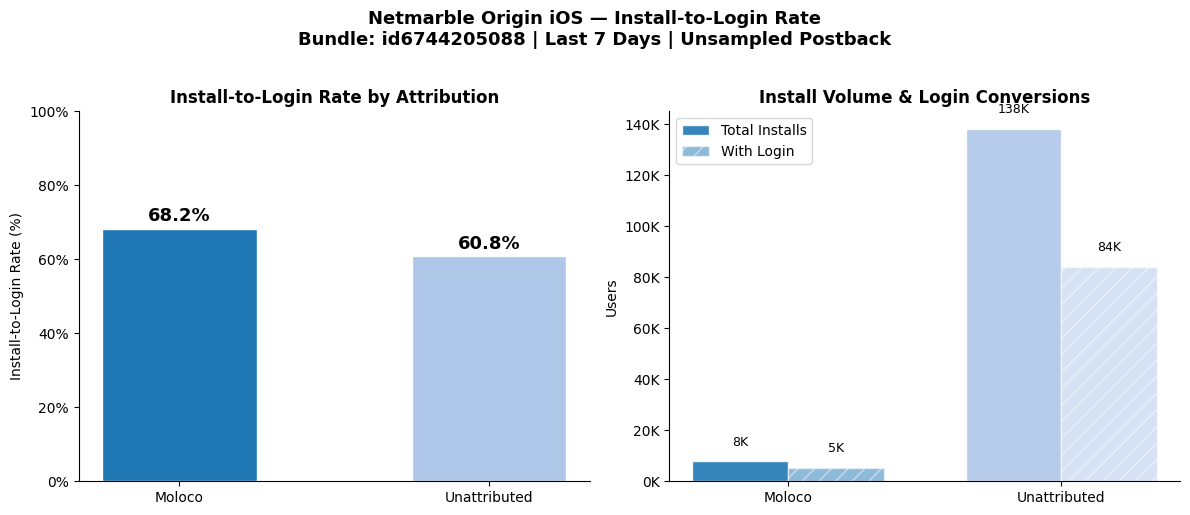

In [19]:
colors = {'Moloco': '#1f77b4', 'Unattributed': '#aec7e8'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Netmarble Origin iOS — Install-to-Login Rate\nBundle: id6744205088 | Last 7 Days | Unsampled Postback',
             fontsize=13, fontweight='bold', y=1.02)

# Chart 1: Rate comparison
ax1 = axes[0]
bars = ax1.bar(df1['attribution_group'], df1['install_to_login_rate_pct'],
               color=[colors[g] for g in df1['attribution_group']], width=0.5, edgecolor='white')
ax1.set_title('Install-to-Login Rate by Attribution', fontweight='bold')
ax1.set_ylabel('Install-to-Login Rate (%)')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for bar, val in zip(bars, df1['install_to_login_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

# Chart 2: Volume funnel
ax2 = axes[1]
x = np.arange(len(df1))
width = 0.35
b1 = ax2.bar(x - width/2, df1['total_installs'], width, label='Total Installs',
             color=[colors[g] for g in df1['attribution_group']], alpha=0.9, edgecolor='white')
b2 = ax2.bar(x + width/2, df1['users_with_login'], width, label='With Login',
             color=[colors[g] for g in df1['attribution_group']], alpha=0.5, edgecolor='white', hatch='//')
ax2.set_title('Install Volume & Login Conversions', fontweight='bold')
ax2.set_ylabel('Users')
ax2.set_xticks(x)
ax2.set_xticklabels(df1['attribution_group'])
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend()
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

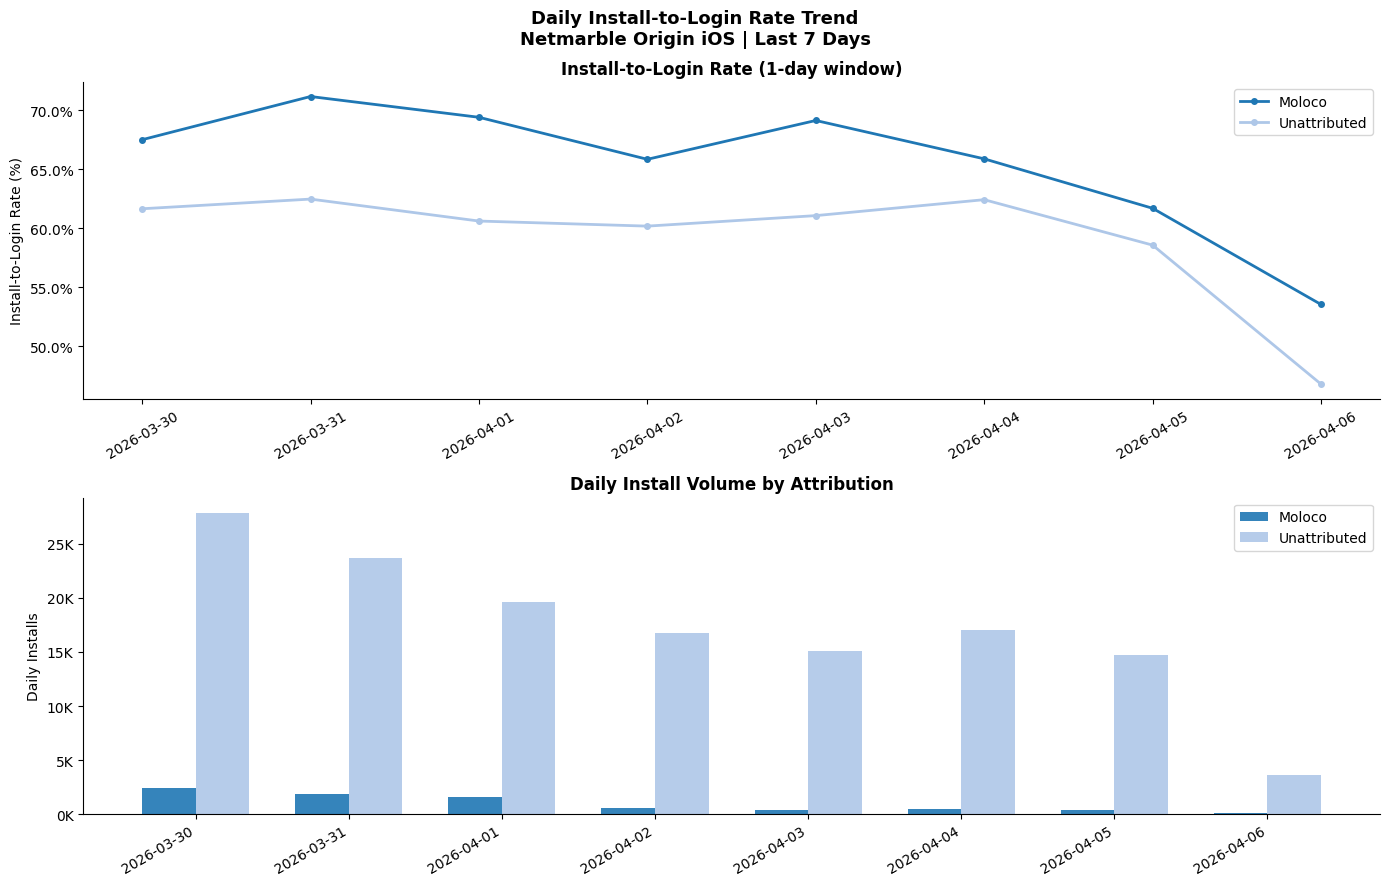

In [20]:
import matplotlib.dates as mdates

# Chart 3: Daily trend
df2['install_date'] = pd.to_datetime(df2['install_date'])
moloco_d = df2[df2['attribution_group'] == 'Moloco'].sort_values('install_date')
unattr_d  = df2[df2['attribution_group'] == 'Unattributed'].sort_values('install_date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Daily Install-to-Login Rate Trend\nNetmarble Origin iOS | Last 7 Days', fontweight='bold', fontsize=13)

# Line chart — uses datetime x-axis
ax1.plot(moloco_d['install_date'], moloco_d['install_to_login_rate_pct'],
         color=colors['Moloco'], marker='o', markersize=4, label='Moloco', linewidth=2)
ax1.plot(unattr_d['install_date'], unattr_d['install_to_login_rate_pct'],
         color=colors['Unattributed'], marker='o', markersize=4, label='Unattributed', linewidth=2)
ax1.set_ylabel('Install-to-Login Rate (%)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.tick_params(axis='x', rotation=30)
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Install-to-Login Rate (1-day window)', fontweight='bold')

# Bar chart — use numeric positions for clean side-by-side grouping
all_dates = sorted(df2['install_date'].unique())
date_to_x = {d: i for i, d in enumerate(all_dates)}
width = 0.35

xm = [date_to_x[d] for d in moloco_d['install_date']]
xu = [date_to_x[d] for d in unattr_d['install_date']]

ax2.bar([x - width/2 for x in xm], moloco_d['total_installs'],
        width=width, color=colors['Moloco'], label='Moloco', alpha=0.9)
ax2.bar([x + width/2 for x in xu], unattr_d['total_installs'],
        width=width, color=colors['Unattributed'], label='Unattributed', alpha=0.9)
ax2.set_xticks(range(len(all_dates)))
ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in all_dates], rotation=30, ha='right')
ax2.set_ylabel('Daily Installs')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Daily Install Volume by Attribution', fontweight='bold')

plt.tight_layout()
plt.show()